In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'D:\Tự Học\hcm-house-price-prediction\data\processed\data_cleaned_colab.csv')

Phân phối dữ liệu (Distribution)

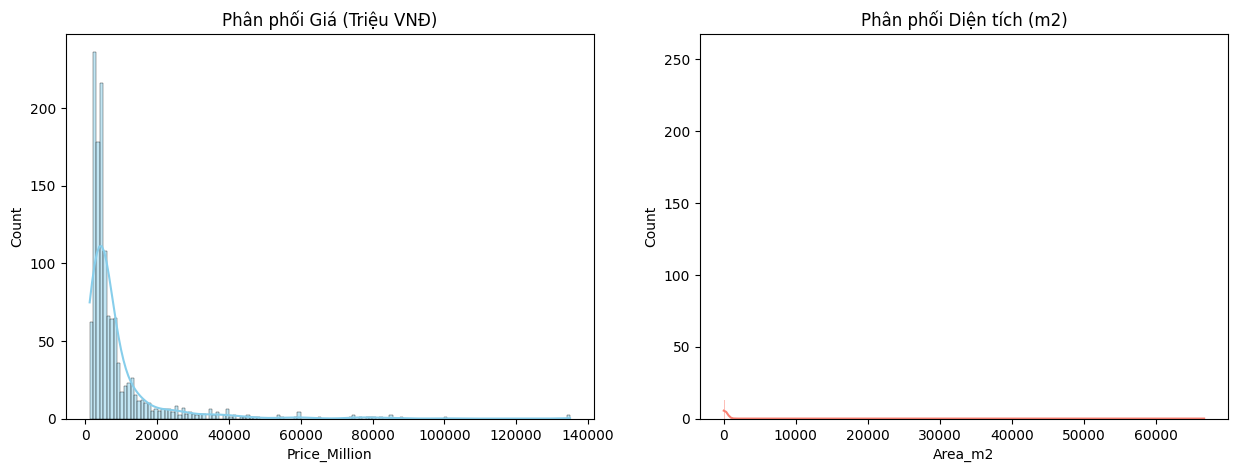

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Price_Million'], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Phân phối Giá (Triệu VNĐ)')

sns.histplot(df['Area_m2'], kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Phân phối Diện tích (m2)')

plt.show()

Ma trận tương quan (Heatmap Correlation)

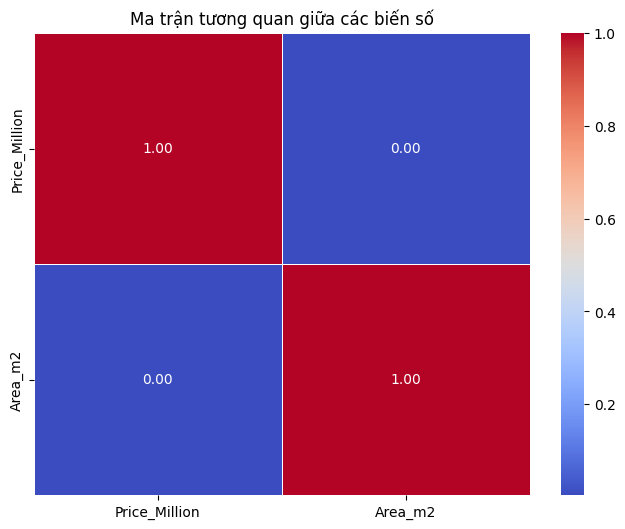

In [4]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

Phát hiện Outlier (Boxplot)

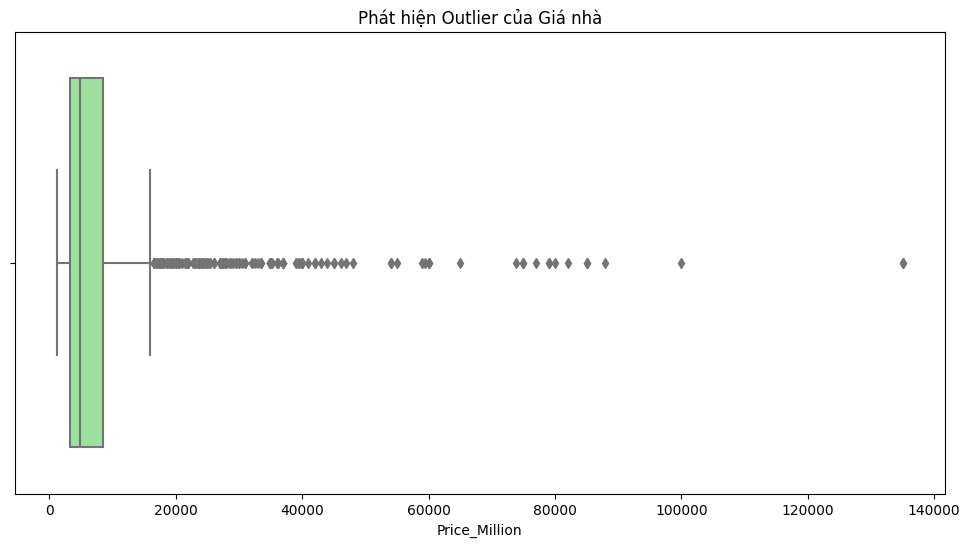

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Price_Million'], color='lightgreen')
plt.title('Phát hiện Outlier của Giá nhà')
plt.show()

Kiểm tra giá trị thiếu (Missing Values)

In [6]:
missing_data = df.isnull().sum()
print("Thống kê giá trị thiếu trên mỗi cột:")
print(missing_data[missing_data > 0] if missing_data.any() else "Không có giá trị thiếu.")

Thống kê giá trị thiếu trên mỗi cột:
Không có giá trị thiếu.


Xây dựng & so sánh nhiều mô hình (Linear Regression, Random Forest, XGBoost)

--- Linear Regression ---
MAE: 0.0777
R2 Score: 1.0000

--- Random Forest ---
MAE: 40.1402
R2 Score: 0.8447

--- XGBoost ---
MAE: 30.7619
R2 Score: 0.9115

Lưu ý: Không thể load model cũ từ đường dẫn (Kiểm tra lại file pkl): [Errno 2] No such file or directory: 'D:\\Tự Học\\models\\best_model.pkl'


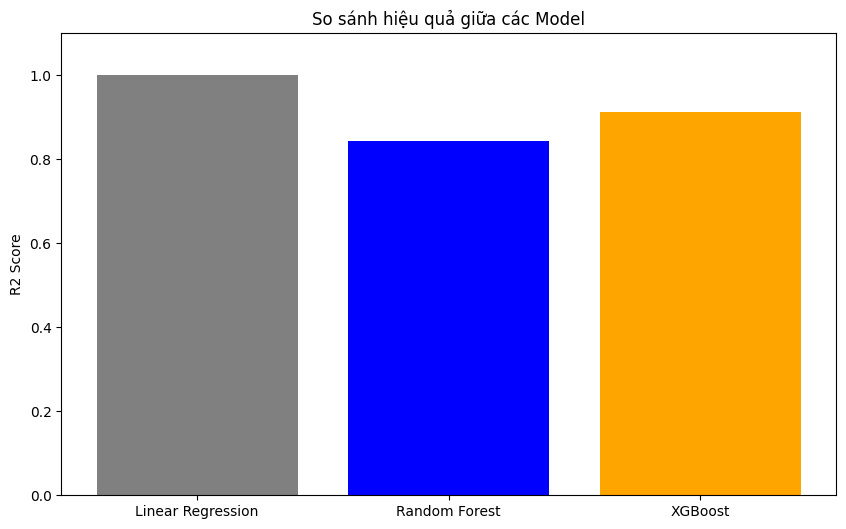

In [9]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import make_regression

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---

X, y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- BƯỚC 2: KHỞI TẠO CÁC MODEL ---
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# --- BƯỚC 3: HUẤN LUYỆN VÀ ĐÁNH GIÁ ---
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = r2
    print(f"--- {name} ---")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}\n")

# --- BƯỚC 4: LOAD VÀ ĐÁNH GIÁ MODEL CŨ CỦA BẠN ---
try:
    old_model = joblib.load(r'D:\Tự Học\models\best_model.pkl')
    y_pred_old = old_model.predict(X_test)
    old_r2 = r2_score(y_test, y_pred_old)
    print(f"--- Best Model từ ổ D ---")
    print(f"R2 Score: {old_r2:.4f}")
    results["Old Best Model"] = old_r2
except Exception as e:
    print(f"Lưu ý: Không thể load model cũ từ đường dẫn (Kiểm tra lại file pkl): {e}")

# --- BƯỚC 5: TRỰC QUAN HÓA SO SÁNH ---
if results:
    plt.figure(figsize=(10, 6))
    plt.bar(results.keys(), results.values(), color=['gray', 'blue', 'orange', 'green'])
    plt.ylabel('R2 Score')
    plt.title('So sánh hiệu quả giữa các Model')
    plt.ylim(0, 1.1)
    plt.show()